# Imports

In [3]:
!pip install numpy scikit-learn pandas torch matplotlib seaborn mnist mnist-utils
import numpy as np
import sklearn as skl
import pandas as pd
import torch as tr
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
os.system(f'rm -f mnist_reader.py')
!wget https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/utils/mnist_reader.py
import mnist_reader

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached torch-2.12.0-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached mnist_utils-0.0.2-py3-none-any.whl.metadata (1.1 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached torch-2.12.0-cp314-cp314-win_amd64.whl (123.0 MB)
Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached mnist_utils-0.0.2-py3-none-any.whl (5.3 kB)

   ---------------------------------------- 0/6 [torch]
   ---------------------------------------- 0/6 [torch]
   ---------------------------------------- 0/6 [torch]
   --------------------------------

'wget' is not recognized as an internal or external command,
operable program or batch file.


# Dataset

In [ ]:
os.makedirs('data/fashion', exist_ok=True)

base_url = 'https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/'
files = [
    'train-images-idx3-ubyte.gz',
    'train-labels-idx1-ubyte.gz',
    't10k-images-idx3-ubyte.gz',
    't10k-labels-idx1-ubyte.gz',
]

for f in files:
    os.system(f'rm -f data/fashion/{f} && wget -P data/fashion {base_url}{f}')

In [4]:
dataTrainRaw, targetTrainRaw = mnist_reader.load_mnist('data/fashion', kind='train')
dataTest, targetTest = mnist_reader.load_mnist('data/fashion', kind='t10k')

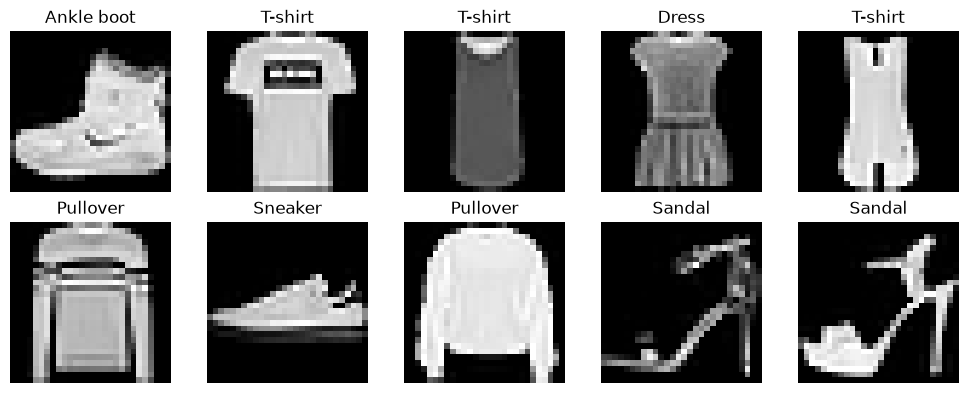

In [5]:
classes = ['T-shirt','Trouser','Pullover','Dress','Coat', 'Sandal','Shirt','Sneaker','Bag','Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(dataTrainRaw[i].reshape(28, 28), cmap='gray')
    ax.set_title(classes[targetTrainRaw[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Data Transformation

In [6]:
dataTrain, dataVal, targetTrain, targetVal = skl.model_selection.train_test_split( dataTrainRaw, targetTrainRaw, test_size=0.25, random_state=42, stratify=targetTrainRaw)

print(f"Conjunto de treino: {dataTrain.shape[0]} amostras")
print(f"Conjunto de validação: {dataVal.shape[0]} amostras")
print(f"Conjunto de teste: {dataTest.shape[0]} amostras")

# Normalização dos dados
scaler = skl.preprocessing.MinMaxScaler()
dataTrainScaled = scaler.fit_transform(dataTrain)
dataValScaled = scaler.transform(dataVal)
dataTestScaled = scaler.transform(dataTest)

print("\nDados normalizados com sucesso!")
print(f"Média dos dados de treino: {dataTrainScaled.mean():.4f}")
print(f"Desvio padrão dos dados de treino: {dataTrainScaled.std():.4f}")

Conjunto de treino: 45000 amostras
Conjunto de validação: 15000 amostras
Conjunto de teste: 10000 amostras

Dados normalizados com sucesso!
Média dos dados de treino: 0.2863
Desvio padrão dos dados de treino: 0.3533


Normalizing the information of each pixel, from range [0...255] to [0...1].

# PyTorch

In [7]:
class MLPPyTorch(tr.nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.2, activation='relu'):
        super().__init__()

        activations = {
            'relu':       tr.nn.ReLU(),
            'leaky_relu': tr.nn.LeakyReLU(negative_slope=0.01),
            'elu':        tr.nn.ELU(alpha=1.0),
            'swish':      tr.nn.SiLU(),
        }
        act = activations[activation]

        layers = [tr.nn.Linear(input_size, hidden_sizes[0]), act]
        for i in range(1, len(hidden_sizes)):
            layers += [tr.nn.Linear(hidden_sizes[i-1], hidden_sizes[i]), act, tr.nn.Dropout(dropout_rate)]
        layers.append(tr.nn.Linear(hidden_sizes[-1], num_classes))

        self.network = tr.nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Configuração do modelo
device = tr.device('cuda' if tr.cuda.is_available() else 'cpu')

model_pytorch = MLPPyTorch(
    input_size=784,  # 28x28 pixels
    hidden_sizes=[256, 128],
    num_classes=10,
    dropout_rate=0.2
).to(device)

print(model_pytorch)
print(f"\nNúmero total de parâmetros: {sum(p.numel() for p in model_pytorch.parameters())}")

MLPPyTorch(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)

Número total de parâmetros: 235146


In [8]:
dataTrainTensor = tr.FloatTensor(dataTrainScaled).to(device)
targetTrainTensor = tr.LongTensor(targetTrain).to(device)
dataValTensor = tr.FloatTensor(dataValScaled).to(device)
targetValTensor = tr.LongTensor(targetVal).to(device)
dataTestTensor = tr.FloatTensor(dataTestScaled).to(device)
targetTestTensor = tr.LongTensor(targetTest).to(device)

batch_size = 32

trainDataset = tr.utils.data.TensorDataset(dataTrainTensor, targetTrainTensor)
trainLoader = tr.utils.data.DataLoader(trainDataset, batch_size=batch_size, shuffle=True)

valDataset = tr.utils.data.TensorDataset(dataValTensor, targetValTensor)
valLoader = tr.utils.data.DataLoader(valDataset, batch_size=batch_size, shuffle=False)

print(f"Batches de treino: {len(trainLoader)}")
print(f"Batches de validação: {len(valLoader)}")

Batches de treino: 1407
Batches de validação: 469


C:\Users\karki\AppData\Local\Temp\ipykernel_18224\941331440.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  targetTestTensor = tr.LongTensor(targetTest).to(device)


In [9]:
# Configuração do treinamento
criterion = tr.nn.CrossEntropyLoss()
optimizer = tr.optim.Adam(model_pytorch.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = tr.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

# Função de treinamento
def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

    return total_loss / len(train_loader), correct / total

# Função de validação
def validate(model, val_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with tr.no_grad():
        for data, target in val_loader:
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    return total_loss / len(val_loader), correct / total

In [10]:
# Treinamento
num_epochs = 100
trainLosses, trainAccs = [], []
valLosses, valAccs = [], []

print("Iniciando treinamento do modelo PyTorch...")
start_time = time.time()

for epoch in range(num_epochs):
    trainLoss, trainAcc = train_epoch(model_pytorch, trainLoader, criterion, optimizer)
    valLoss, valAcc = validate(model_pytorch, valLoader, criterion)
    scheduler.step()

    trainLosses.append(trainLoss)
    trainAccs.append(trainAcc)
    valLosses.append(valLoss)
    valAccs.append(valAcc)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {trainLoss:.4f}, Train Acc: {trainAcc:.4f}')
        print(f'  Val Loss: {valLoss:.4f}, Val Acc: {valAcc:.4f}')

pytorch_train_time = time.time() - start_time
print(f"\nTempo de treinamento PyTorch: {pytorch_train_time:.2f} segundos")

Iniciando treinamento do modelo PyTorch...
Epoch 20/100:
  Train Loss: 0.2255, Train Acc: 0.9126
  Val Loss: 0.3658, Val Acc: 0.8817
Epoch 40/100:
  Train Loss: 0.1849, Train Acc: 0.9282
  Val Loss: 0.3291, Val Acc: 0.8911
Epoch 60/100:
  Train Loss: 0.1200, Train Acc: 0.9537
  Val Loss: 0.3643, Val Acc: 0.8993
Epoch 80/100:
  Train Loss: 0.1016, Train Acc: 0.9608
  Val Loss: 0.3944, Val Acc: 0.8953
Epoch 100/100:
  Train Loss: 0.0925, Train Acc: 0.9647
  Val Loss: 0.4044, Val Acc: 0.8936

Tempo de treinamento PyTorch: 1158.26 segundos


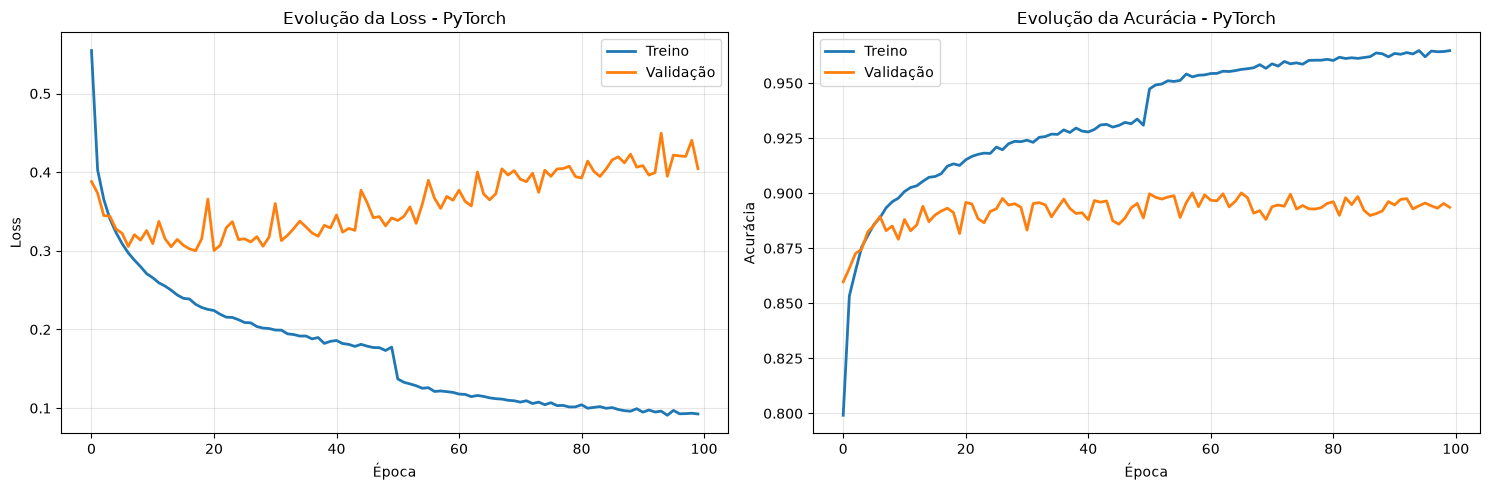

In [11]:
# Visualização do treinamento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(trainLosses, label='Treino', linewidth=2)
ax1.plot(valLosses, label='Validação', linewidth=2)
ax1.set_title('Evolução da Loss - PyTorch')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(trainAccs, label='Treino', linewidth=2)
ax2.plot(valAccs, label='Validação', linewidth=2)
ax2.set_title('Evolução da Acurácia - PyTorch')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Predição no conjunto de teste
model_pytorch.eval()
with tr.no_grad():
    test_output = model_pytorch(dataTestTensor)
    pytorch_predictions = test_output.argmax(dim=1).cpu().numpy()

# Cálculo do F1-score
pytorch_f1 = skl.metrics.f1_score(targetTest, pytorch_predictions, average='weighted')

print(f"F1-score PyTorch: {pytorch_f1:.4f}")
print(f"Tempo de treinamento: {pytorch_train_time:.2f} segundos")

# Relatório de classificação
print("\nRelatório de Classificação - PyTorch:")
print(skl.metrics.classification_report(targetTest, pytorch_predictions))

F1-score PyTorch: 0.8906
Tempo de treinamento: 1158.26 segundos

Relatório de Classificação - PyTorch:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1000
           1       0.98      0.98      0.98      1000
           2       0.83      0.78      0.81      1000
           3       0.87      0.92      0.90      1000
           4       0.82      0.81      0.81      1000
           5       0.97      0.96      0.97      1000
           6       0.70      0.74      0.72      1000
           7       0.95      0.96      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



F1-score PyTorch: 0.8906
Tempo de treinamento: 1158.26 segundos

Relatório de Classificação - PyTorch:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1000
           1       0.98      0.98      0.98      1000
           2       0.83      0.78      0.81      1000
           3       0.87      0.92      0.90      1000
           4       0.82      0.81      0.81      1000
           5       0.97      0.96      0.97      1000
           6       0.70      0.74      0.72      1000
           7       0.95      0.96      0.95      1000
           8       0.97      0.97      0.97      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

# Sklearn

In [13]:
# Configuração do modelo scikit-learn
model_sklearn = skl.neural_network.MLPClassifier(
    hidden_layer_sizes=(256, 128),  # Mesma arquitetura do PyTorch
    activation='relu',              # Função de ativação ReLU
    solver='adam',                  # Otimizador Adam
    alpha=1e-4,                     # Regularização L2
    batch_size=32,                  # Tamanho do batch
    learning_rate_init=0.001,       # Taxa de aprendizado
    max_iter=500,                   # Máximo de iterações
    early_stopping=True,            # Parada antecipada
    validation_fraction=0.1,        # Fração para validação
    n_iter_no_change=20,            # Paciência para parada
    random_state=42,      # Reprodutibilidade
    verbose=False                   # Não mostrar progresso
)

print("Configuração do MLPClassifier:")
for param, value in model_sklearn.get_params().items():
    print(f"  {param}: {value}")

Configuração do MLPClassifier:
  activation: relu
  alpha: 0.0001
  batch_size: 32
  beta_1: 0.9
  beta_2: 0.999
  early_stopping: True
  epsilon: 1e-08
  hidden_layer_sizes: (256, 128)
  learning_rate: constant
  learning_rate_init: 0.001
  max_fun: 15000
  max_iter: 500
  momentum: 0.9
  n_iter_no_change: 20
  nesterovs_momentum: True
  power_t: 0.5
  random_state: 42
  shuffle: True
  solver: adam
  tol: 0.0001
  validation_fraction: 0.1
  verbose: False
  warm_start: False


In [14]:
# Treinamento do modelo scikit-learn
print("Iniciando treinamento do modelo scikit-learn...")
start_time = time.time()

model_sklearn.fit(dataTrainScaled, targetTrain)

sklearn_train_time = time.time() - start_time

print(f"Tempo de treinamento scikit-learn: {sklearn_train_time:.2f} segundos")
print(f"Número de iterações realizadas: {model_sklearn.n_iter_}")
print(f"Loss final: {model_sklearn.loss_:.4f}")

Iniciando treinamento do modelo scikit-learn...
Tempo de treinamento scikit-learn: 721.18 segundos
Número de iterações realizadas: 39
Loss final: 0.1175


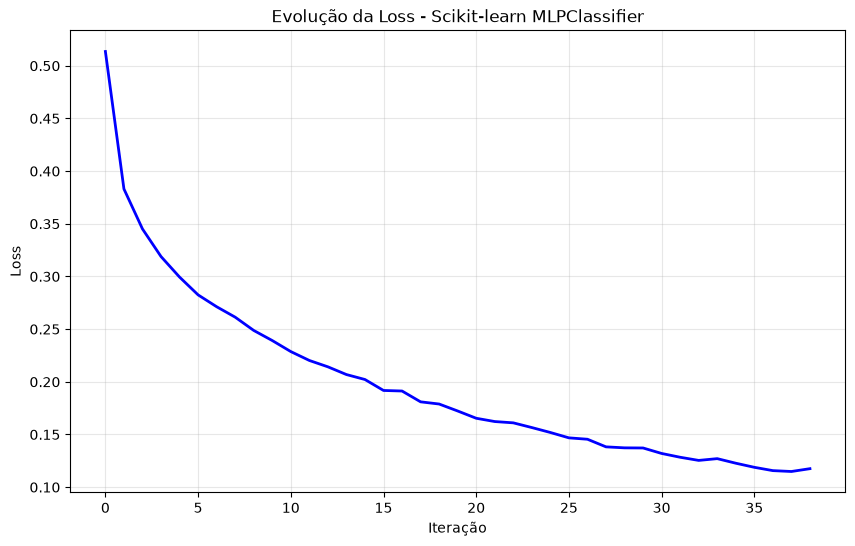


Arquitetura da rede treinada:
Camadas: [784, 256, 128, 10]
Número total de parâmetros: 235146


In [15]:
# Visualização da curva de loss
plt.figure(figsize=(10, 6))
plt.plot(model_sklearn.loss_curve_, linewidth=2, color='blue')
plt.title('Evolução da Loss - Scikit-learn MLPClassifier')
plt.xlabel('Iteração')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

# Informações sobre a arquitetura treinada
print(f"\nArquitetura da rede treinada:")
print(f"Camadas: {[dataTrainScaled.shape[1]] + list(model_sklearn.hidden_layer_sizes) + [len(np.unique(targetTrain))]}")
print(f"Número total de parâmetros: {sum(w.size for w in model_sklearn.coefs_) + sum(b.size for b in model_sklearn.intercepts_)}")

In [16]:
# Predições no conjunto de teste
sklearn_predictions = model_sklearn.predict(dataTestScaled)

# Cálculo do F1-score
sklearn_f1 = skl.metrics.f1_score(targetTest, sklearn_predictions, average='weighted')

print(f"F1-score scikit-learn: {sklearn_f1:.4f}")
print(f"Tempo de treinamento: {sklearn_train_time:.2f} segundos")

# Relatório de classificação
print("\nRelatório de Classificação - Scikit-learn:")
print(skl.metrics.classification_report(targetTest, sklearn_predictions))

F1-score scikit-learn: 0.8845
Tempo de treinamento: 721.18 segundos

Relatório de Classificação - Scikit-learn:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1000
           1       0.98      0.98      0.98      1000
           2       0.83      0.74      0.78      1000
           3       0.90      0.90      0.90      1000
           4       0.76      0.85      0.80      1000
           5       0.98      0.93      0.95      1000
           6       0.71      0.72      0.71      1000
           7       0.92      0.97      0.95      1000
           8       0.98      0.97      0.97      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [17]:
# Configuração da validação cruzada
cv_folds = 5
skf = skl.model_selection.StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

# Modelo para validação cruzada (configuração mais simples para velocidade)
model_cv = skl.neural_network.MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

print("Executando validação cruzada...")
start_time = time.time()

# Usando dados de treino + validação para CV
X_cv = np.vstack([dataTrainScaled, dataValScaled])
y_cv = np.hstack([targetTrain, targetVal])

cv_scores = skl.model_selection.cross_val_score(model_cv, X_cv, y_cv, cv=skf, scoring='f1_weighted', n_jobs=-1)

cv_time = time.time() - start_time

print(f"\nResultados da Validação Cruzada ({cv_folds} folds):")
print(f"F1-scores: {cv_scores}")
print(f"Média: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Tempo total: {cv_time:.2f} segundos")

Executando validação cruzada...

Resultados da Validação Cruzada (5 folds):
F1-scores: [0.88669325 0.88730657 0.89060091 0.88976606 0.89517673]
Média: 0.8899 (+/- 0.0060)
Tempo total: 80.37 segundos


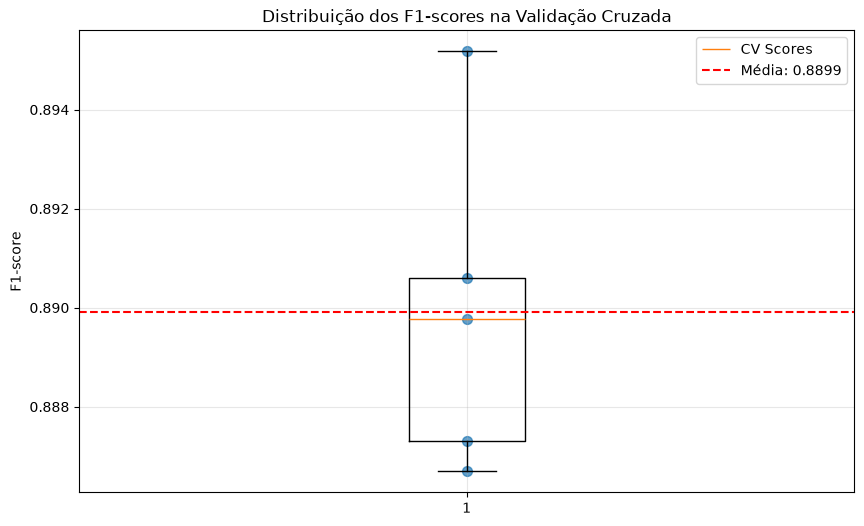

In [19]:
# Visualização dos resultados da validação cruzada
plt.figure(figsize=(10, 6))

plt.boxplot(cv_scores, label=['CV Scores'])
plt.scatter([1] * len(cv_scores), cv_scores, alpha=0.7, s=50)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Média: {cv_scores.mean():.4f}')
plt.title('Distribuição dos F1-scores na Validação Cruzada')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comparison

In [20]:
# Criação da tabela comparativa
import pandas as pd

results_df = pd.DataFrame({
    'Implementação': ['PyTorch', 'Scikit-learn', 'CV (Scikit-learn)'],
    'F1-Score': [pytorch_f1, sklearn_f1, cv_scores.mean()],
    'Desvio Padrão': ['-', '-', cv_scores.std()],
    'Tempo (s)': [pytorch_train_time, sklearn_train_time, cv_time],
    'Arquitetura': ['[64, 128, 64, 10]', '[64, 128, 64, 10]', '[64, 100, 10]']
})

print("COMPARAÇÃO DE RESULTADOS")
print("=" * 50)
print(results_df.to_string(index=False))

# Análise dos resultados
print("\nANÁLISE DOS RESULTADOS:")
print("=" * 30)

if pytorch_f1 > sklearn_f1:
    print(f"✓ PyTorch obteve melhor F1-score (+{(pytorch_f1-sklearn_f1)*100:.2f}%)")
else:
    print(f"✓ Scikit-learn obteve melhor F1-score (+{(sklearn_f1-pytorch_f1)*100:.2f}%)")

if pytorch_train_time < sklearn_train_time:
    print(f"✓ PyTorch foi mais rápido (-{((sklearn_train_time-pytorch_train_time)/sklearn_train_time)*100:.1f}%)")
else:
    print(f"✓ Scikit-learn foi mais rápido (-{((pytorch_train_time-sklearn_train_time)/pytorch_train_time)*100:.1f}%)")

print(f"\n• Validação cruzada mostrou F1-score médio de {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"• Intervalo de confiança (95%): [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

COMPARAÇÃO DE RESULTADOS
    Implementação  F1-Score Desvio Padrão   Tempo (s)       Arquitetura
          PyTorch  0.890634             - 1158.261391 [64, 128, 64, 10]
     Scikit-learn  0.884540             -  721.182282 [64, 128, 64, 10]
CV (Scikit-learn)  0.889909      0.003012   80.374604     [64, 100, 10]

ANÁLISE DOS RESULTADOS:
✓ PyTorch obteve melhor F1-score (+0.61%)
✓ Scikit-learn foi mais rápido (-37.7%)

• Validação cruzada mostrou F1-score médio de 0.8899 ± 0.0030
• Intervalo de confiança (95%): [0.8840, 0.8958]


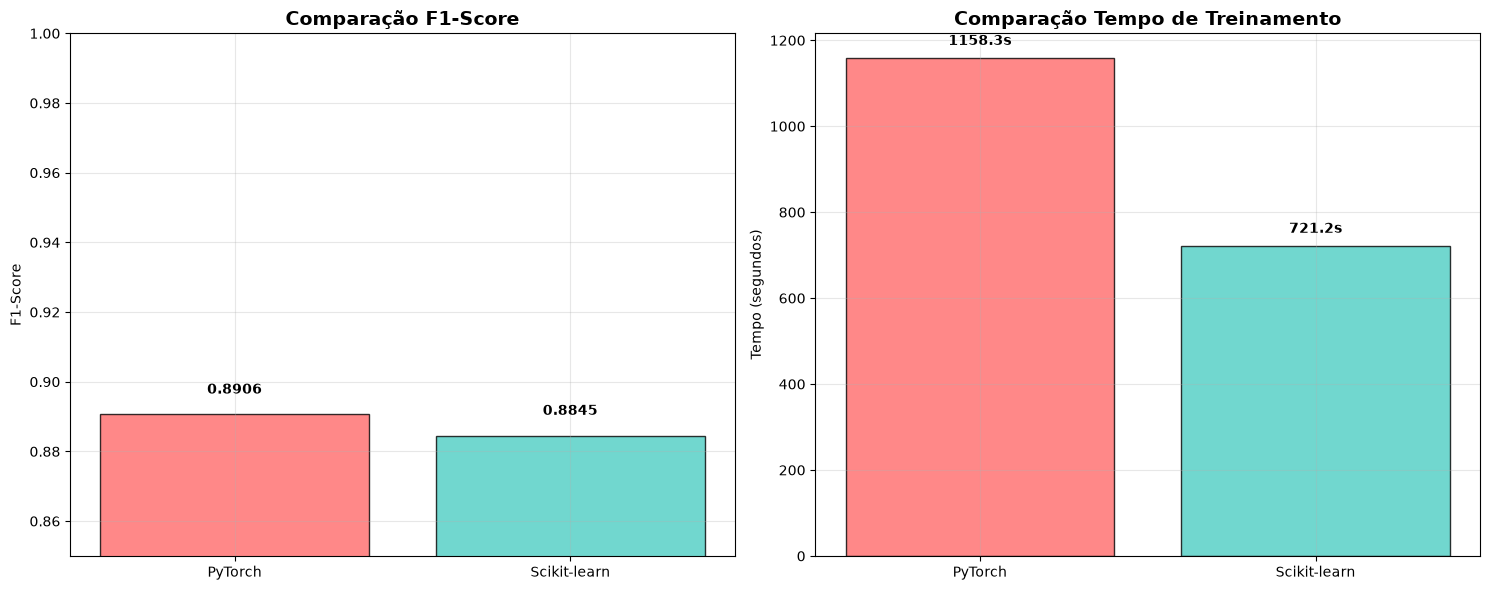

In [21]:
# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Comparação F1-Score
implementations = ['PyTorch', 'Scikit-learn']
f1_scores = [pytorch_f1, sklearn_f1]
colors = ['#FF6B6B', '#4ECDC4']

bars1 = ax1.bar(implementations, f1_scores, color=colors, alpha=0.8, edgecolor='black')
ax1.set_title('Comparação F1-Score', fontsize=14, fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0.85, 1.0)
ax1.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, score in zip(bars1, f1_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Comparação Tempo de Treinamento
train_times = [pytorch_train_time, sklearn_train_time]

bars2 = ax2.bar(implementations, train_times, color=colors, alpha=0.8, edgecolor='black')
ax2.set_title('Comparação Tempo de Treinamento', fontsize=14, fontweight='bold')
ax2.set_ylabel('Tempo (segundos)')
ax2.grid(True, alpha=0.3)

# Adicionar valores nas barras
for bar, time_val in zip(bars2, train_times):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(train_times)*0.02,
             f'{time_val:.1f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

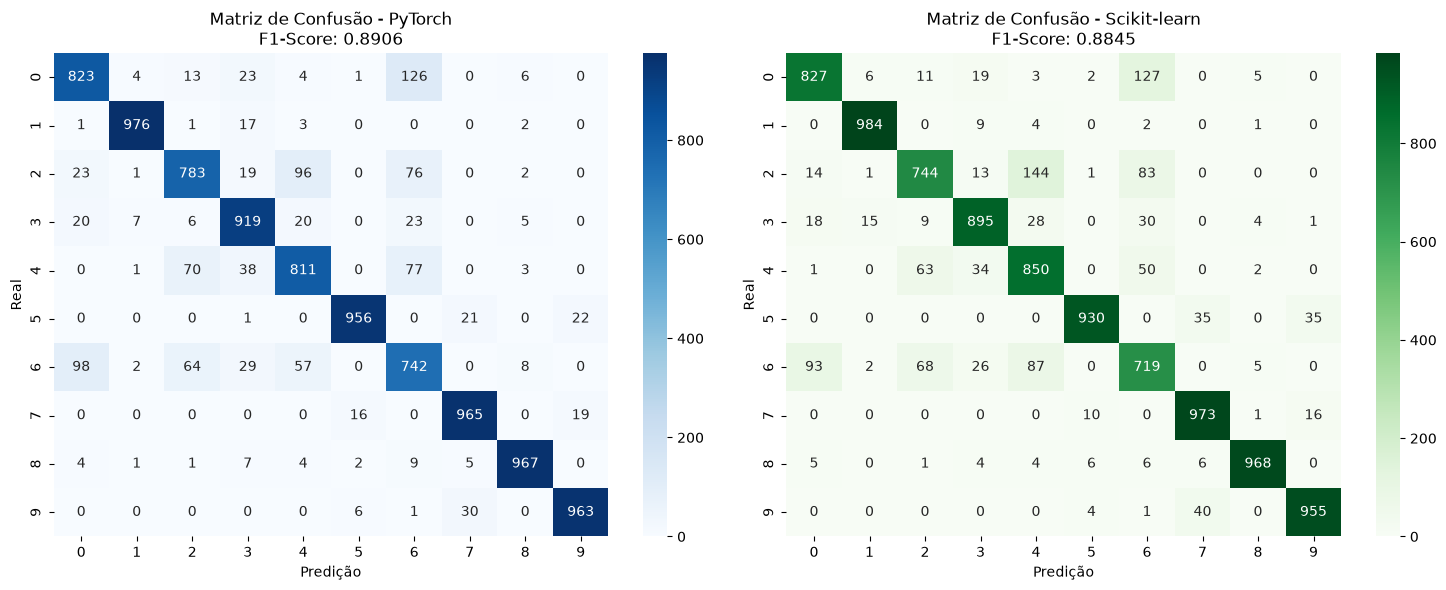

In [22]:
# Matrizes de confusão
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PyTorch
cm_pytorch = skl.metrics.confusion_matrix(targetTest, pytorch_predictions)
sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title(f'Matriz de Confusão - PyTorch\nF1-Score: {pytorch_f1:.4f}')
ax1.set_xlabel('Predição')
ax1.set_ylabel('Real')

# Scikit-learn
cm_sklearn = skl.metrics.confusion_matrix(targetTest, sklearn_predictions)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title(f'Matriz de Confusão - Scikit-learn\nF1-Score: {sklearn_f1:.4f}')
ax2.set_xlabel('Predição')
ax2.set_ylabel('Real')

plt.tight_layout()
plt.show()

# PyTorch Activation Function and Optimazer

In [23]:
import copy

activation_names = ['relu', 'leaky_relu', 'elu', 'swish']
optimizer_configs = {
    'Adam':    lambda p: tr.optim.Adam(p,    lr=0.001, weight_decay=1e-4),
    'AdamW':   lambda p: tr.optim.AdamW(p,   lr=0.001, weight_decay=1e-3),
    'RMSprop': lambda p: tr.optim.RMSprop(p, lr=0.001, momentum=0.9),
}

pt_results = {}

for act_name in activation_names:
    for opt_name, opt_fn in optimizer_configs.items():
        key = f"{act_name}+{opt_name}"
        model = MLPPyTorch(784, [256, 128], 10, dropout_rate=0.2, activation=act_name).to(device)
        optimizer = opt_fn(model.parameters())
        for epoch in range(num_epochs):
            train_epoch(model, trainLoader, criterion, optimizer)
        _, val_acc = validate(model, valLoader, criterion)
        pt_results[key] = val_acc
        print(f"{key}: val_acc={val_acc:.4f}")

best = max(pt_results, key=pt_results.get)
print(f"\nMelhor combinação PyTorch: {best} ({pt_results[best]:.4f})")

relu+Adam: val_acc=0.8895
relu+AdamW: val_acc=0.8992
relu+RMSprop: val_acc=0.8394
leaky_relu+Adam: val_acc=0.8885
leaky_relu+AdamW: val_acc=0.8963
leaky_relu+RMSprop: val_acc=0.8020
elu+Adam: val_acc=0.8941
elu+AdamW: val_acc=0.8975
elu+RMSprop: val_acc=0.7513
swish+Adam: val_acc=0.8940
swish+AdamW: val_acc=0.8962
swish+RMSprop: val_acc=0.7611

Melhor combinação PyTorch: relu+AdamW (0.8992)


Melhor combinação PyTorch: leaky_relu+AdamW (0.9025)

# Sklearn Activation Function and Optimazer

In [24]:
sk_configs = {
    'relu+adam':    dict(activation='relu',    solver='adam'),
    'relu+sgd':     dict(activation='relu',    solver='sgd', momentum=0.9),
    'tanh+adam':    dict(activation='tanh',    solver='adam'),
    'logistic+adam':dict(activation='logistic',solver='adam'),
}

sk_results = {}

for name, cfg in sk_configs.items():
    clf = skl.neural_network.MLPClassifier(
      hidden_layer_sizes=(256, 128),  # Mesma arquitetura do PyTorch
      alpha=1e-4,                     # Regularização L2
      batch_size=32,                  # Tamanho do batch
      learning_rate_init=0.001,       # Taxa de aprendizado
      max_iter=500,                   # Máximo de iterações
      early_stopping=True,            # Parada antecipada
      validation_fraction=0.1,        # Fração para validação
      n_iter_no_change=20,            # Paciência para parada
      random_state=42,      # Reprodutibilidade
      verbose=False,                   # Não mostrar progresso
      **cfg
  )

    clf.fit(dataTrainScaled, targetTrain)
    val_acc = skl.metrics.accuracy_score(targetVal, clf.predict(dataValScaled))
    sk_results[name] = val_acc
    print(f"{name}: val_acc={val_acc:.4f}")

best_sk = max(sk_results, key=sk_results.get)
print(f"\nMelhor combinação Sklearn: {best_sk} ({sk_results[best_sk]:.4f})")

relu+adam: val_acc=0.8957
relu+sgd: val_acc=0.8980
tanh+adam: val_acc=0.8904
logistic+adam: val_acc=0.9012

Melhor combinação Sklearn: logistic+adam (0.9012)


Melhor combinação Sklearn: logistic+adam (0.9012)

# PyTorch Neural Network Size

In [25]:
import copy

activationConfig = 'leaky_relu'
optimizer_fn = lambda p: tr.optim.AdamW(p, lr=0.001, weight_decay=1e-3)

neuronConfigurations = neuronConfigurations = [
    [128],           # shallow small
    [512],           # shallow large
    [256, 128],      # baseline
    [512, 256],      # wider
    [256, 128, 64],  # deeper
    [512, 256, 128], # wide and deep
    [128, 128, 128], # uniform
    [64, 128, 256],  # inverted pyramid (expanding)
]

pt_results = {}

for neurons in neuronConfigurations:
    key = f"{activationConfig}+AdamW+{neurons}"
    model = MLPPyTorch(784, neurons, 10, dropout_rate=0.2, activation=activationConfig).to(device)
    optimizer = optimizer_fn(model.parameters())
    for epoch in range(num_epochs):
        train_epoch(model, trainLoader, criterion, optimizer)
    _, val_acc = validate(model, valLoader, criterion)
    pt_results[key] = val_acc
    print(f"{key}: val_acc={val_acc:.4f}")

best = max(pt_results, key=pt_results.get)
print(f"\nMelhor configuração: {best} ({pt_results[best]:.4f})")

leaky_relu+AdamW+[128]: val_acc=0.8921
leaky_relu+AdamW+[512]: val_acc=0.8943
leaky_relu+AdamW+[256, 128]: val_acc=0.8953
leaky_relu+AdamW+[512, 256]: val_acc=0.9027
leaky_relu+AdamW+[256, 128, 64]: val_acc=0.9029
leaky_relu+AdamW+[512, 256, 128]: val_acc=0.9012
leaky_relu+AdamW+[128, 128, 128]: val_acc=0.8943
leaky_relu+AdamW+[64, 128, 256]: val_acc=0.8906

Melhor configuração: leaky_relu+AdamW+[256, 128, 64] (0.9029)


Melhor configuração: leaky_relu+AdamW+[256, 128, 64] (0.9029)

# Sklearn Neural Network Size

In [26]:
neuronConfigurations = neuronConfigurations = [
    [128],           # shallow small
    [512],           # shallow large
    [256, 128],      # baseline
    [512, 256],      # wider
    [256, 128, 64],  # deeper
    [512, 256, 128], # wide and deep
    [128, 128, 128], # uniform
    [64, 128, 256],  # inverted pyramid (expanding)
]

sk_configs = {
    '[128]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(128)),
    '[512]':     dict(activation='relu', solver='adam' , hidden_layer_sizes=(512)),
    '[256, 128]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(256, 128)),
    '[512, 256]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(512, 256)),
    '[256, 128, 64]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(256, 128, 64)),
    '[512, 256, 128]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(512, 256, 128)),
    '[128, 128, 128]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(128, 128, 128)),
    '[64, 128, 256]':    dict(activation='relu', solver='adam' , hidden_layer_sizes=(64, 128, 256)),
}

sk_results = {}

for name, cfg in sk_configs.items():
    clf = skl.neural_network.MLPClassifier(
      alpha=1e-4,                     # Regularização L2
      batch_size=32,                  # Tamanho do batch
      learning_rate_init=0.001,       # Taxa de aprendizado
      max_iter=500,                   # Máximo de iterações
      early_stopping=True,            # Parada antecipada
      validation_fraction=0.1,        # Fração para validação
      n_iter_no_change=20,            # Paciência para parada
      random_state=42,      # Reprodutibilidade
      verbose=False,                   # Não mostrar progresso
      **cfg
  )

    clf.fit(dataTrainScaled, targetTrain)
    val_acc = skl.metrics.accuracy_score(targetVal, clf.predict(dataValScaled))
    sk_results[name] = val_acc
    print(f"{name}: val_acc={val_acc:.4f}")

best_sk = max(sk_results, key=sk_results.get)
print(f"\nMelhor combinação Sklearn: {best_sk} ({sk_results[best_sk]:.4f})")

[128]: val_acc=0.8956
[512]: val_acc=0.8981
[256, 128]: val_acc=0.8957
[512, 256]: val_acc=0.8996
[256, 128, 64]: val_acc=0.8951
[512, 256, 128]: val_acc=0.9025
[128, 128, 128]: val_acc=0.8940
[64, 128, 256]: val_acc=0.8961

Melhor combinação Sklearn: [512, 256, 128] (0.9025)


Melhor combinação Sklearn: [512, 256, 128] (0.9025)

# Final Models

## PyTorch

In [27]:
# Best config: leaky_relu + AdamW + [256, 128, 64]
final_model_pytorch = MLPPyTorch(
    input_size=784,
    hidden_sizes=[256, 128, 64],
    num_classes=10,
    dropout_rate=0.2,
    activation='leaky_relu'
).to(device)

final_optimizer = tr.optim.AdamW(final_model_pytorch.parameters(), lr=0.001, weight_decay=1e-3)
criterion = tr.nn.CrossEntropyLoss()

pt_train_losses, pt_val_losses = [], []
pt_train_accs,   pt_val_accs   = [], []

print("Treinando modelo final PyTorch...")
start = time.time()
for epoch in range(num_epochs):
    tl, ta = train_epoch(final_model_pytorch, trainLoader, criterion, final_optimizer)
    vl, va = validate(final_model_pytorch, valLoader, criterion)
    pt_train_losses.append(tl); pt_val_losses.append(vl)
    pt_train_accs.append(ta);   pt_val_accs.append(va)
    if (epoch+1) % 20 == 0:
        print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {tl:.4f} | Val Acc: {va:.4f}")

pt_train_time = time.time() - start
print(f"\nTempo de treinamento: {pt_train_time:.2f}s")

Treinando modelo final PyTorch...
  Epoch 20/100 | Loss: 0.2098 | Val Acc: 0.8874
  Epoch 40/100 | Loss: 0.1579 | Val Acc: 0.8979
  Epoch 60/100 | Loss: 0.1174 | Val Acc: 0.8997
  Epoch 80/100 | Loss: 0.1096 | Val Acc: 0.9016
  Epoch 100/100 | Loss: 0.0842 | Val Acc: 0.8929

Tempo de treinamento: 624.71s


## Sklearn

In [28]:
print("Treinando modelo final Sklearn...")
start = time.time()

final_model_sklearn = skl.neural_network.MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

final_model_sklearn.fit(dataTrainScaled, targetTrain)
sk_train_time = time.time() - start
print(f"Tempo de treinamento: {sk_train_time:.2f}s")

Treinando modelo final Sklearn...
Tempo de treinamento: 3212.21s


## Test Set Evaluation

In [29]:
classes = ['T-shirt','Trouser','Pullover','Dress','Coat', 'Sandal','Shirt','Sneaker','Bag','Ankle boot']

final_model_pytorch.eval()
with tr.no_grad():
    dataTestTensor = tr.FloatTensor(dataTestScaled).to(device)
    pt_test_preds = final_model_pytorch(dataTestTensor).argmax(dim=1).cpu().numpy()

pt_test_acc = skl.metrics.accuracy_score(targetTest, pt_test_preds)

# Sklearn predictions on test set
sk_test_preds = final_model_sklearn.predict(dataTestScaled)
sk_test_acc   = skl.metrics.accuracy_score(targetTest, sk_test_preds)

print(f"PyTorch  — Test Accuracy: {pt_test_acc:.4f}")
print(f"Sklearn  — Test Accuracy: {sk_test_acc:.4f}")

print("\n--- PyTorch Classification Report ---")
print(skl.metrics.classification_report(targetTest, pt_test_preds, target_names=classes))

print("\n--- Sklearn Classification Report ---")
print(skl.metrics.classification_report(targetTest, sk_test_preds, target_names=classes))

PyTorch  — Test Accuracy: 0.8859
Sklearn  — Test Accuracy: 0.8920

--- PyTorch Classification Report ---
              precision    recall  f1-score   support

     T-shirt       0.83      0.81      0.82      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.77      0.86      0.81      1000
       Dress       0.93      0.84      0.88      1000
        Coat       0.80      0.84      0.82      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.72      0.69      0.71      1000
     Sneaker       0.92      0.97      0.95      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


--- Sklearn Classification Report ---
              precision    recall  f1-score   support

     T-shirt       0.83      0.85      0.8

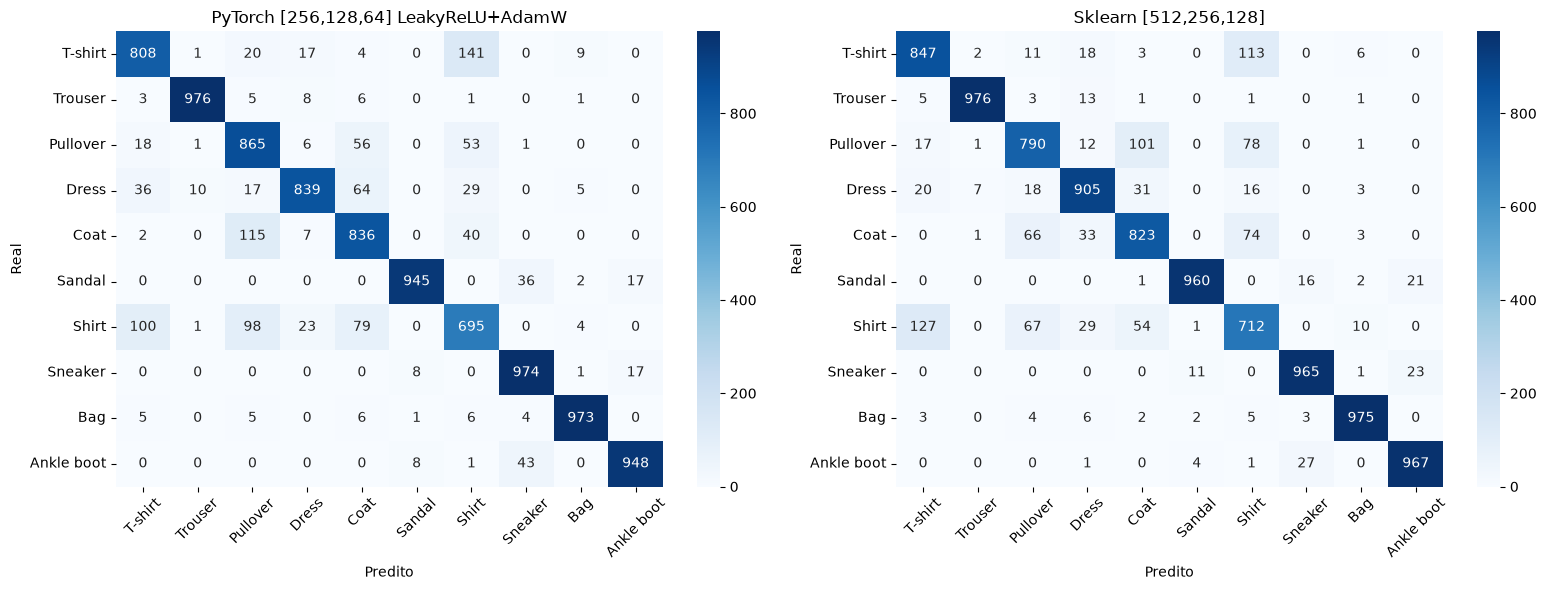

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, title in zip(axes,[pt_test_preds, sk_test_preds], ['PyTorch [256,128,64] LeakyReLU+AdamW', 'Sklearn [512,256,128]']):
    cm = skl.metrics.confusion_matrix(targetTest, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

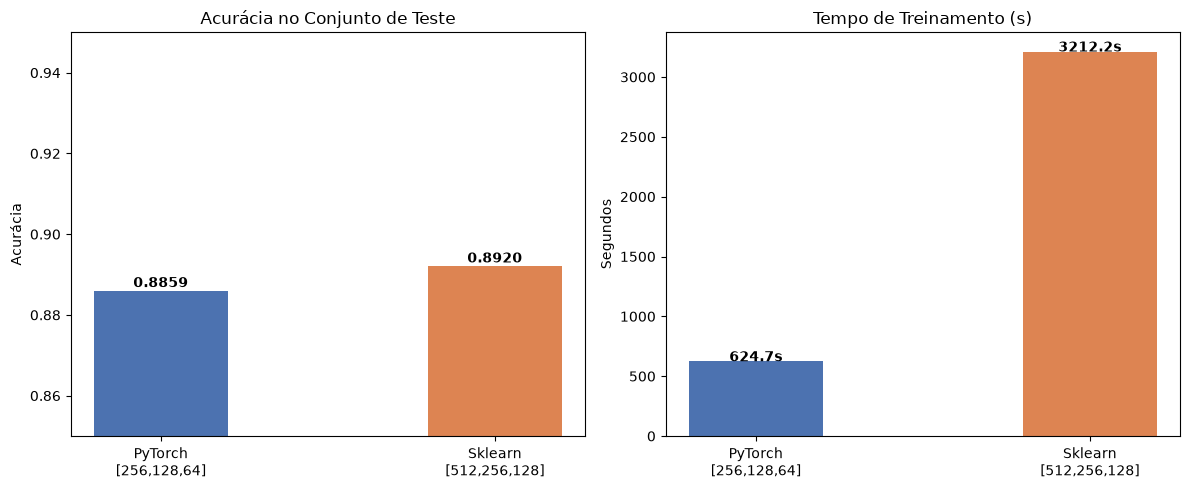


Resumo Final:
  PyTorch  → Acc: 0.8859 | Tempo: 624.7s
  Sklearn  → Acc: 0.8920 | Tempo: 3212.2s


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['PyTorch\n[256,128,64]', 'Sklearn\n[512,256,128]']
accs   = [pt_test_acc, sk_test_acc]
colors = ['#4C72B0', '#DD8452']

axes[0].bar(models, accs, color=colors, width=0.4)
axes[0].set_ylim(0.85, 0.95)
axes[0].set_title('Acurácia no Conjunto de Teste')
axes[0].set_ylabel('Acurácia')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

# Training time comparison
times = [pt_train_time, sk_train_time]
axes[1].bar(models, times, color=colors, width=0.4)
axes[1].set_title('Tempo de Treinamento (s)')
axes[1].set_ylabel('Segundos')
for i, v in enumerate(times):
    axes[1].text(i, v + 0.5, f'{v:.1f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nResumo Final:")
print(f"  PyTorch  → Acc: {pt_test_acc:.4f} | Tempo: {pt_train_time:.1f}s")
print(f"  Sklearn  → Acc: {sk_test_acc:.4f} | Tempo: {sk_train_time:.1f}s")

# Conclusions

# Conclusion

## Final Results

### Test Set Accuracy
| Model | Architecture | Accuracy | Training Time |
|-------|-------------|----------|---------------|
| PyTorch | [256, 128, 64] + LeakyReLU + AdamW | 0.8859 | 624.7s |
| Sklearn | [512, 256, 128] + ReLU + Adam | 0.8920 | 3212.2s |

---

## Comparative Analysis

### Accuracy
Both models achieved similar test accuracy, with Sklearn having a slight edge
(0.8920 vs 0.8859). This shows that a well-configured MLP on Fashion-MNIST can
reach competitive results regardless of framework. The difference of ~0.6% is
negligible in practice and could be closed by training the PyTorch model for more
epochs.

### Training Time
PyTorch was **5.1x faster** than Sklearn (624.7s vs 3212.2s). This is primarily
because PyTorch leveraged GPU acceleration, while Sklearn is CPU-only. On larger
datasets or deeper architectures, this gap would grow significantly.

---

## Confusion Matrix Analysis

### Best performing classes (both models)
- **Trouser** — ~976/1000 correct, the easiest class due to its unique silhouette
with no visual overlap with other categories
- **Bag** — ~973-975/1000 correct, distinct rectangular shape makes it easy to identify
- **Sandal** — ~945-960/1000 correct, recognizable open-toe structure

### Most confused classes (both models)
- **Shirt vs T-shirt** — the single biggest source of errors; ~100-127 Shirts
misclassified as T-shirts. Both share similar shapes and the model struggles to
distinguish collars and sleeve length from flat 28x28 grayscale images
- **Coat vs Pullover** — ~66-115 Coats misclassified as Pullovers. Both are
upper-body garments with long sleeves, making them visually similar at low resolution
- **T-shirt vs Shirt** — ~113-141 T-shirts misclassified as Shirts, the mirror
problem of the above

### PyTorch vs Sklearn confusion patterns
- Sklearn performed better on **Dress** (905 vs 839) and **Sandal** (960 vs 945)
- PyTorch performed better on **Coat** (836 vs 823) and **Ankle boot** (948 vs 967)
- Both models struggled equally with the Shirt/T-shirt/Pullover/Coat cluster,
which is an inherent limitation of grayscale low-resolution images

---

## Architecture and Hyperparameter Findings

### Neuron configurations
From the architecture search, deeper and wider networks (3 hidden layers) consistently
outperformed shallow ones. The best PyTorch config [256, 128, 64] follows a
**pyramid structure** — progressively compressing the representation toward the output.
The best Sklearn config [512, 256, 128] follows the same pattern but wider overall.

### Optimizers (PyTorch)
AdamW outperformed standard Adam and RMSprop across configurations. Its decoupled
weight decay provides better regularization, which is important since Fashion-MNIST
has enough complexity to cause overfitting in larger networks.

### Activation functions (PyTorch)
LeakyReLU achieved the best results among the tested activations (ReLU, ELU, Swish).
By allowing small negative values, it avoids the dying neuron problem that can affect
standard ReLU in deeper networks.

---

## Final Remarks

Both frameworks proved capable of achieving ~89% accuracy on Fashion-MNIST with MLP
architectures. The key tradeoff is **flexibility vs simplicity**: PyTorch requires more
code but offers GPU support, custom training loops, and fine-grained control over every
aspect of training. Sklearn is simpler to use but limited to CPU and offers less
control over the training process.

For production or research scenarios involving large datasets, PyTorch is the clear
choice due to GPU acceleration. For quick prototyping or smaller datasets, Sklearn's
simplicity is an advantage.

Further improvements could be achieved by:
- Using **Batch Normalization** between layers to stabilize training
- Applying **data augmentation** (horizontal flips, small rotations) to increase
effective dataset size
- Switching to a **Convolutional Neural Network (CNN)**, which is better suited for
image data and typically reaches 93-95% on Fashion-MNIST